# Лабораторна робота №4: Класифікація 
Мета роботи :Ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic.
Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.




Брильова Дар'я КН-43


In [212]:
#1a 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [213]:
#1b 
df = pd.read_csv("train.csv")
print(f"Розмір датасету: {df.shape}")
df.head()


Розмір датасету: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [214]:
#1c Загальна інформація 
print("Інформація про DataFrame:")
df.info()
print("\nКількість пропусків у кожній колонці:")
print(df.isna().sum().sort_values(ascending=False))


Інформація про DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

Кількість пропусків у кожній колонці:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Far

In [215]:
#1d Заповнення пропущених значень, для віку використовуємо медіану, для порту посадки використовуємо моду
if df["Age"].isna().any():
    df["Age"] = df["Age"].fillna(df["Age"].median())

if df["Embarked"].isna().any():
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Пропуски після обробки:")
print(df[["Age", "Embarked"]].isna().sum())


Пропуски після обробки:
Age         0
Embarked    0
dtype: int64


In [216]:
#1e 
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

model_df = df[features + [target]].copy()
model_df = pd.get_dummies(model_df, columns=["Sex", "Embarked"], drop_first=True)

print("Ознаки після кодування:")
print(model_df.columns.tolist())
model_df.head()


Ознаки після кодування:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


In [217]:
#2a Формування матриці ознак 
X = model_df.drop(columns=[target])
y = model_df[target]

print(f"Розмір X: {X.shape}")
print(f"Розмір y: {y.shape}")


Розмір X: (891, 8)
Розмір y: (891,)


In [218]:
#2b 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X_train: (712, 8)
X_test: (179, 8)
y_train: (712,)
y_test: (179,)


In [219]:
#3a Навчання моделі дерева рішень
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42,
)

dt_model.fit(X_train, y_train)
print("Модель успішно навчено.")


Модель успішно навчено.


In [220]:
#3b 
y_pred = dt_model.predict(X_test)

print(f"Глибина дерева: {dt_model.get_depth()}")
print(f"Кількість вузлів: {dt_model.tree_.node_count}")
print("Перші 10 прогнозів:", y_pred[:10])


Глибина дерева: 4
Кількість вузлів: 29
Перші 10 прогнозів: [0 0 0 0 1 0 1 0 0 0]


In [221]:
#4a 
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.7877
Precision: 0.8444
Recall: 0.5507
F1-score: 0.6667


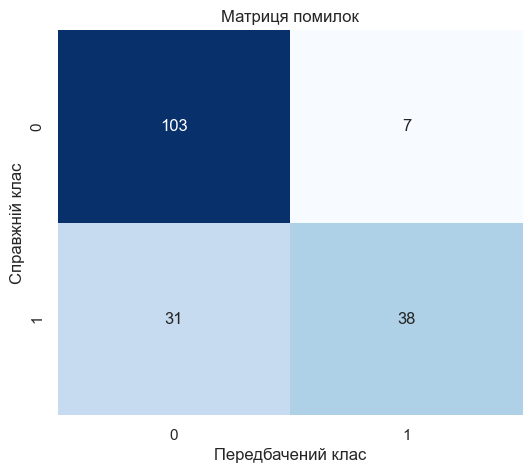

In [222]:
#4b 
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Матриця помилок")
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.show()


In [223]:
#4c звіт класифікації
print(classification_report(y_test, y_pred, digits=4, target_names=["Не вижив", "Вижив"]))


              precision    recall  f1-score   support

    Не вижив     0.7687    0.9364    0.8443       110
       Вижив     0.8444    0.5507    0.6667        69

    accuracy                         0.7877       179
   macro avg     0.8066    0.7435    0.7555       179
weighted avg     0.7979    0.7877    0.7758       179



In [224]:
#4d 
test_balance = y_test.value_counts().sort_index()
test_ratio = (y_test.value_counts(normalize=True).sort_index() * 100).round(2)

print("Кількість об'єктів за класами (тест):")
print(test_balance)
print("\nЧастка класів у тесті (%):")
print(test_ratio)

if test_ratio.min() < 40:
    print("\nУ тестовій вибірці класи помітно незбалансовані, тому Precision/Recall/F1 інформативніші за одну Accuracy.")
else:
    print("\nУ тестовій вибірці класи відносно збалансовані, але Precision/Recall/F1 також важливо враховувати.")


Кількість об'єктів за класами (тест):
Survived
0    110
1     69
Name: count, dtype: int64

Частка класів у тесті (%):
Survived
0    61.45
1    38.55
Name: proportion, dtype: float64

У тестовій вибірці класи помітно незбалансовані, тому Precision/Recall/F1 інформативніші за одну Accuracy.


Важливість ознак:
Sex_male      0.576297
Pclass        0.195920
Age           0.106957
Fare          0.063141
Embarked_S    0.037198
SibSp         0.012109
Parch         0.008377
Embarked_Q    0.000000
dtype: float64


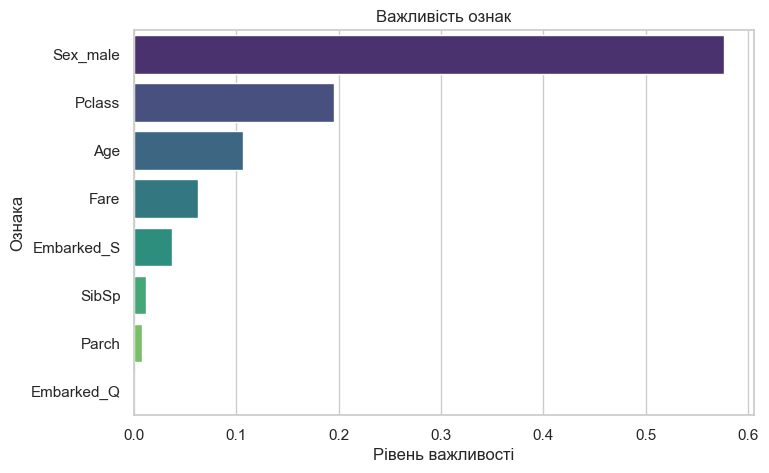

In [225]:
#5a 
feature_importance = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Важливість ознак:")
print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, palette="viridis", legend=False)
plt.title("Важливість ознак")
plt.xlabel("Рівень важливості")
plt.ylabel("Ознака")
plt.show()


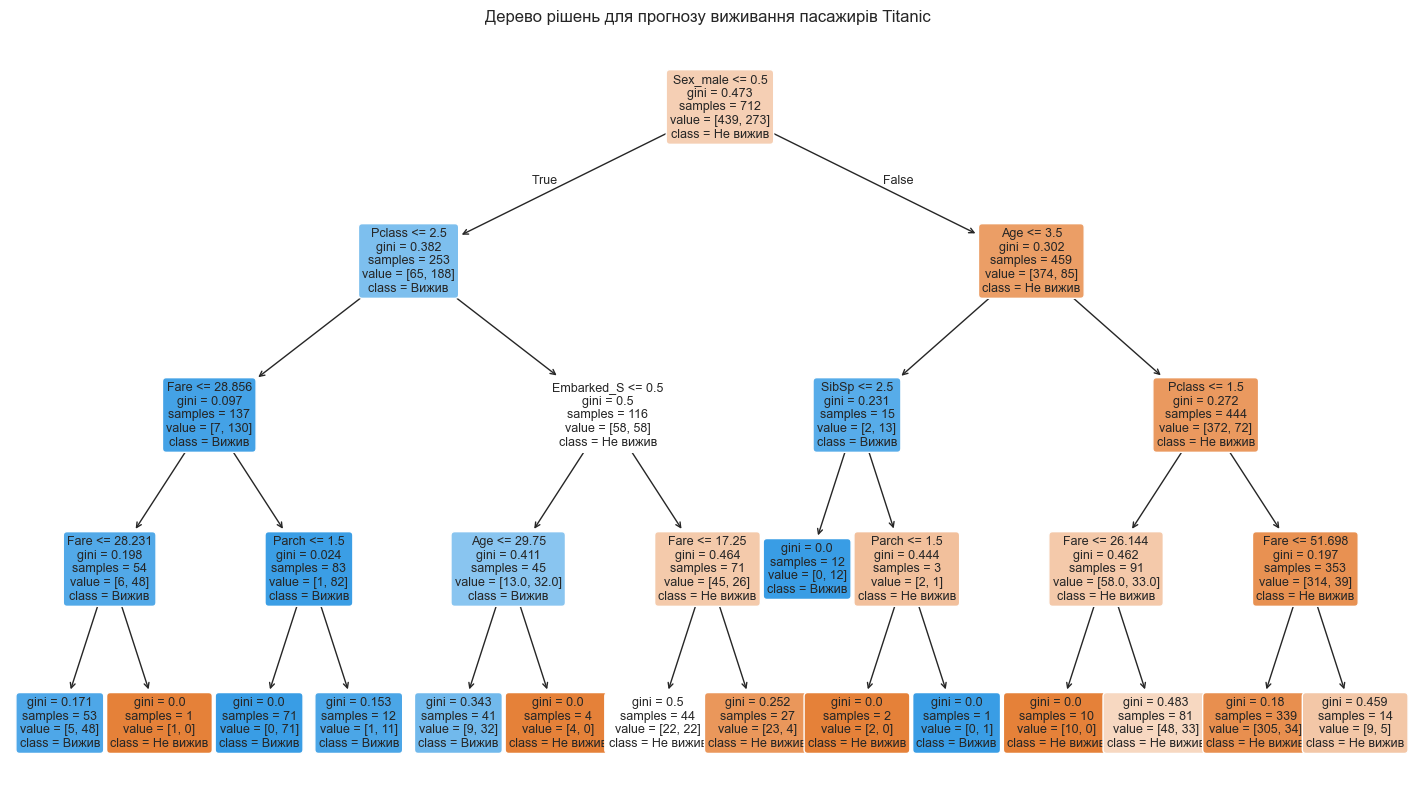

In [226]:
#5b 
plt.figure(figsize=(18, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Не вижив", "Вижив"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Дерево рішень для прогнозу виживання пасажирів Titanic")
plt.show()


Висновки: 
Модель показує, що рішення про виживання найбільше залежить від статі, класу каюти та вартості квитка; вік і родинні ознаки уточнюють прогноз у конкретних підгрупах. За структурою дерева і важливістю ознак видно, що чоловіки значно частіше потрапляють у гілки з прогнозом “не вижив”, тоді як жінки — у гілки з вищою ймовірністю виживання.